<a href="https://colab.research.google.com/github/aman-18-choudhary/Aman_23BDS0337/blob/main/Phase1_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Course Code    : BCSE331L
# Course Name    : Exploratory Data Analysis (EDA)
# Project Title  : EDA Course Project - Phase 1

# Student Name   : Aman
# Register Number: 23BDS0337

# Faculty        : Dr. M. Prakash
# Dataset Source : https://raw.githubusercontent.com/salemprakash/EDA/main/Data/econmath.csv

In [23]:
# Importing libraries required for data analysis and visualization

import pandas as pd                  # For data manipulation
import numpy as np                   # For numerical operations

import matplotlib.pyplot as plt      # For plotting graphs
import seaborn as sns                # For advanced statistical visualizations

# Display plots inside Google Colab
%matplotlib inline

# Set a better plotting style

In [24]:
# URL of the dataset stored on GitHub

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/econmath.csv"

# Reading the CSV file into a DataFrame

df = pd.read_csv(url)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [25]:
df.head()
df.tail()

,rownames,age,work,study,econhs,colgpa,hsgpa,acteng,actmth,act,mathscr,male,calculus,attexc,attgood,fathcoll,mothcoll,score
851,852,19,10.0,9.0,0,3.2115,3.000,20.0,19.0,21.0,5,1,0,0,1,1,0,79.69
852,853,19,20.0,5.0,1,2.3888,3.071,23.0,23.0,22.0,10,1,1,0,1,0,0,78.13
853,854,19,20.0,21.5,1,3.1785,2.971,22.0,27.0,22.0,10,0,1,0,1,1,0,68.75
854,855,19,0.0,10.0,1,2.5892,3.861,21.0,19.0,21.0,9,0,0,0,1,1,0,77.34
855,856,19,0.0,15.0,1,3.7258,3.120,26.0,27.0,28.0,10,1,1,0,1,0,0,91.41


In [26]:
# Display number of rows and columns
print("Shape of Dataset:", df.shape)
print(df.columns)
df.info()

Shape of Dataset: (856, 18)
Index(['rownames', 'age', 'work', 'study', 'econhs', 'colgpa', 'hsgpa',
       'acteng', 'actmth', 'act', 'mathscr', 'male', 'calculus', 'attexc',
       'attgood', 'fathcoll', 'mothcoll', 'score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  856 non-null    int64  
 1   age       856 non-null    int64  
 2   work      856 non-null    float64
 3   study     856 non-null    float64
 4   econhs    856 non-null    int64  
 5   colgpa    856 non-null    float64
 6   hsgpa     856 non-null    float64
 7   acteng    814 non-null    float64
 8   actmth    814 non-null    float64
 9   act       814 non-null    float64
 10  mathscr   856 non-null    int64  
 11  male      856 non-null    int64  
 12  calculus  856 non-null    int64  
 13  attexc    856 non-null    int64  
 14  attgood   856 non

In [27]:
# Generate descriptive statistics
df.describe()
df.describe(include='all')

# Count missing values


print(df.isnull().sum)

<bound method DataFrame.sum of      rownames    age   work  study  econhs  colgpa  hsgpa  acteng  actmth  \
0       False  False  False  False   False   False  False   False   False   
1       False  False  False  False   False   False  False   False   False   
2       False  False  False  False   False   False  False   False   False   
3       False  False  False  False   False   False  False   False   False   
4       False  False  False  False   False   False  False   False   False   
..        ...    ...    ...    ...     ...     ...    ...     ...     ...   
851     False  False  False  False   False   False  False   False   False   
852     False  False  False  False   False   False  False   False   False   
853     False  False  False  False   False   False  False   False   False   
854     False  False  False  False   False   False  False   False   False   
855     False  False  False  False   False   False  False   False   False   

       act  mathscr   male  calculus  attexc

In [28]:
df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values handled successfully.")

Missing values handled successfully.


In [29]:
df.isnull().sum()

,0
rownames,0
age,0
work,0
study,0
econhs,0
colgpa,0
hsgpa,0
acteng,0
actmth,0
act,0


In [30]:
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully.")

# Display updated dataset shape

print(df.shape)

Duplicate Rows: 0
Duplicates Removed Successfully.
(856, 18)


In [31]:
# Import MinMaxScaler for normalization

from sklearn.preprocessing import MinMaxScaler

# Select numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns

# Create scaler object

scaler = MinMaxScaler()

# Create a copy of dataset

df_scaled = df.copy()

# Normalize numerical columns between 0 and 1

df_scaled[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("Data Transformation Completed.")

Data Transformation Completed.


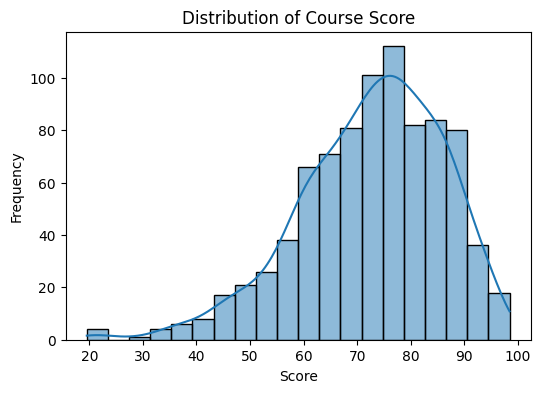

In [32]:
# Histogram of Course Score

plt.figure(figsize=(6,4))

sns.histplot(df["score"], bins=20, kde=True)

plt.title("Distribution of Course Score")

plt.xlabel("Score")

plt.ylabel("Frequency")

plt.show()

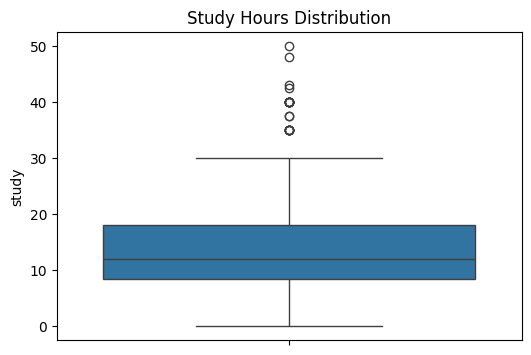

In [33]:
# Box plot to detect outliers in Study Hours

plt.figure(figsize=(6,4))

sns.boxplot(y=df["study"])

plt.title("Study Hours Distribution")

plt.show()

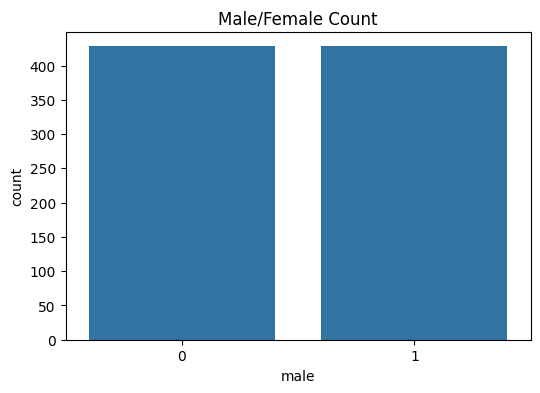

In [34]:
# Count plot for Gender

plt.figure(figsize=(6,4))

sns.countplot(x=df["male"])

plt.title("Male/Female Count")

plt.show()

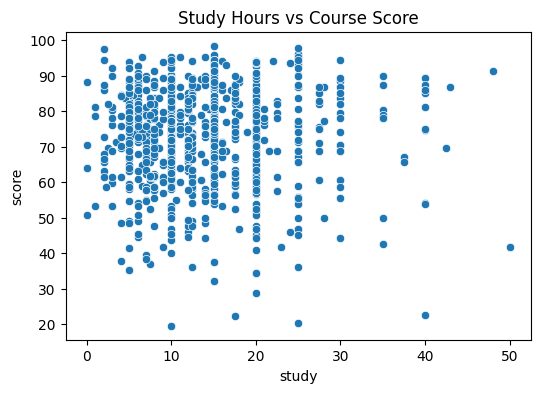

In [35]:
# Relationship between Study Hours and Course Score

plt.figure(figsize=(6,4))

sns.scatterplot(data=df,
                x="study",
                y="score")

plt.title("Study Hours vs Course Score")

plt.show()

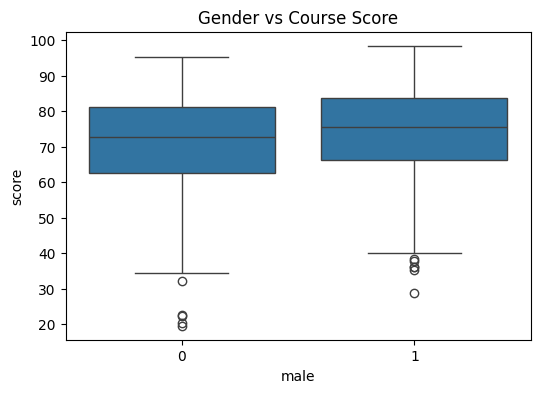

In [36]:
# Compare Course Score based on Gender

plt.figure(figsize=(6,4))

sns.boxplot(data=df,
            x="male",
            y="score")

plt.title("Gender vs Course Score")

plt.show()

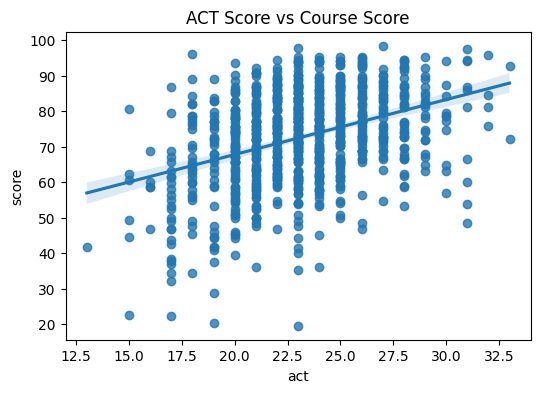

In [37]:
# Relationship between ACT Score and Course Score

plt.figure(figsize=(6,4))

sns.regplot(data=df,
            x="act",
            y="score")

plt.title("ACT Score vs Course Score")

plt.show()

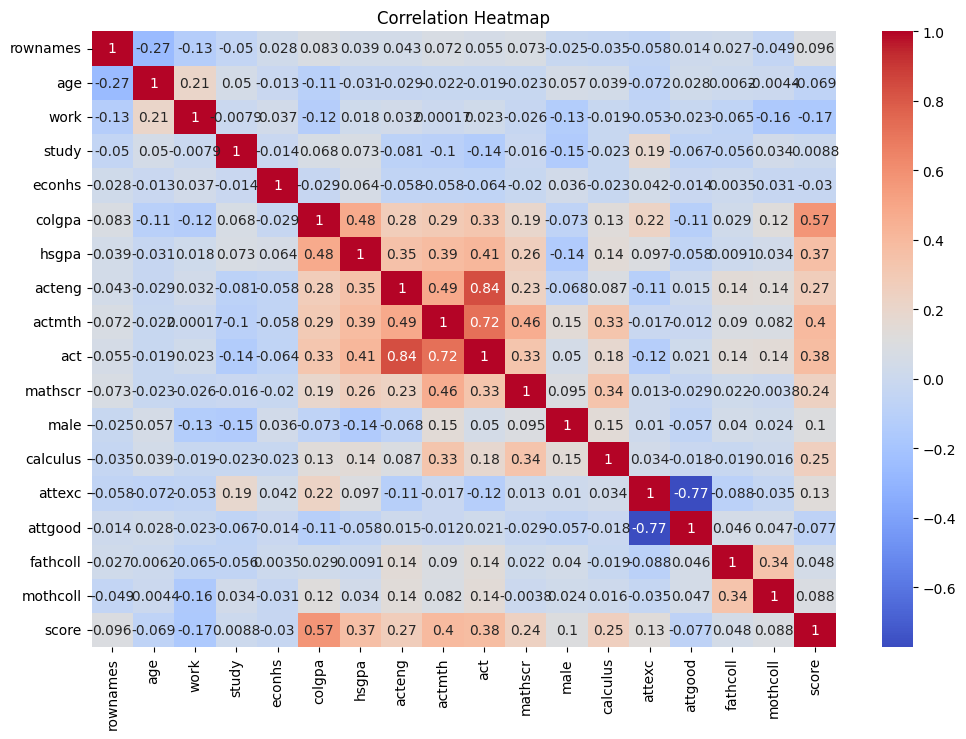

In [38]:
# Correlation matrix between numerical columns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

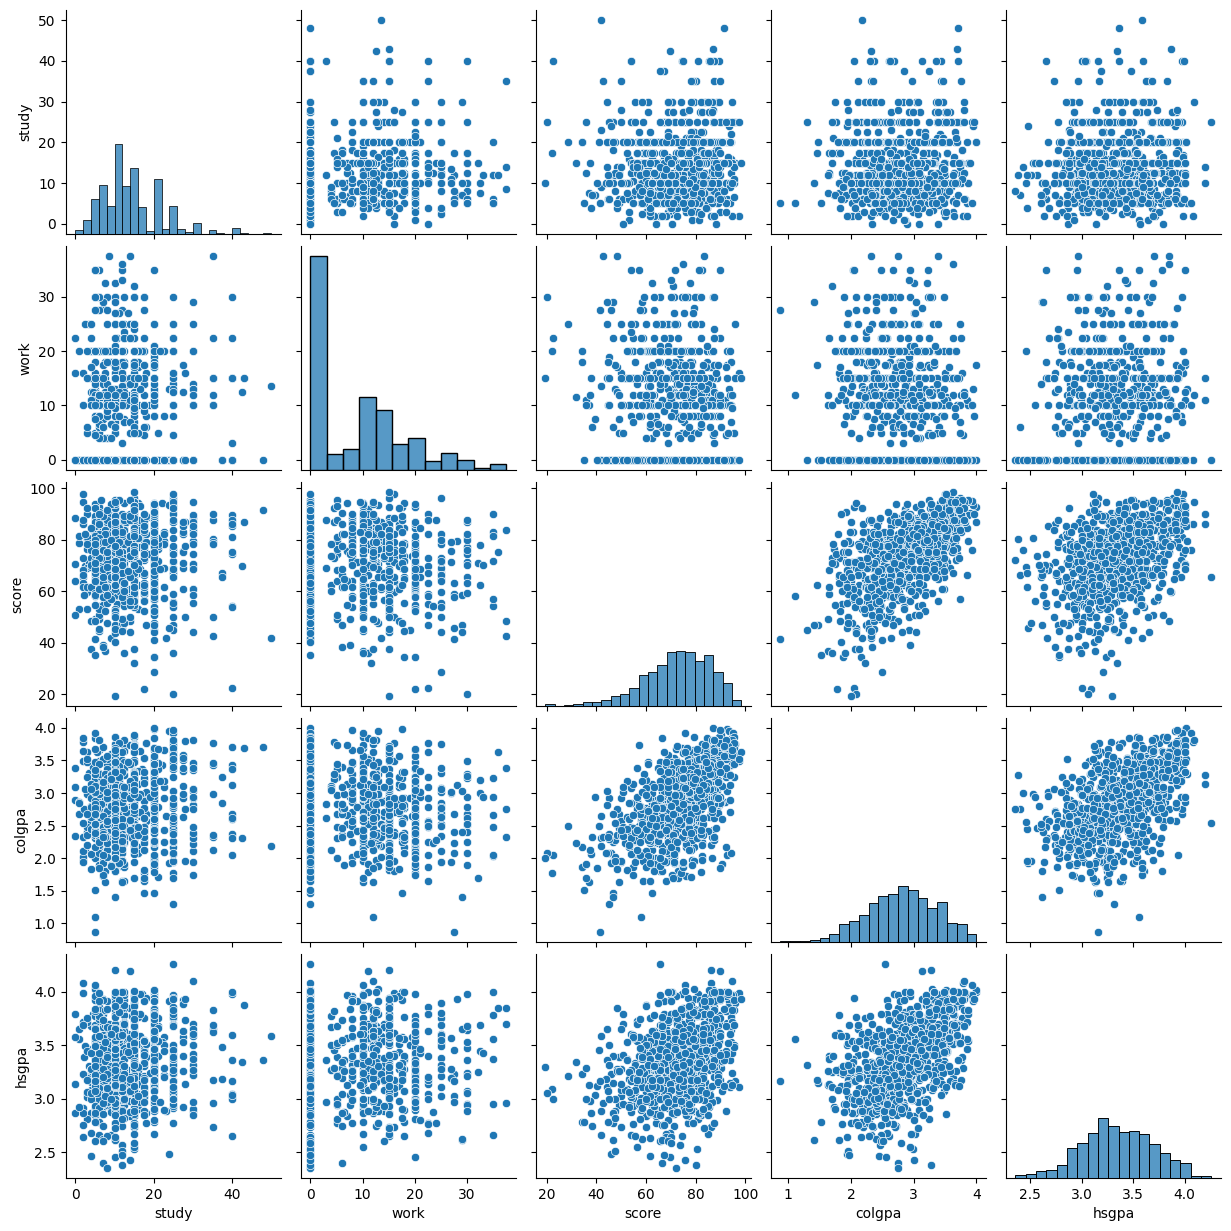

In [39]:
# Pairwise relationship between selected variables

sns.pairplot(df[["study",
                 "work",
                "score",
                "colgpa",
                "hsgpa"]])

plt.show()

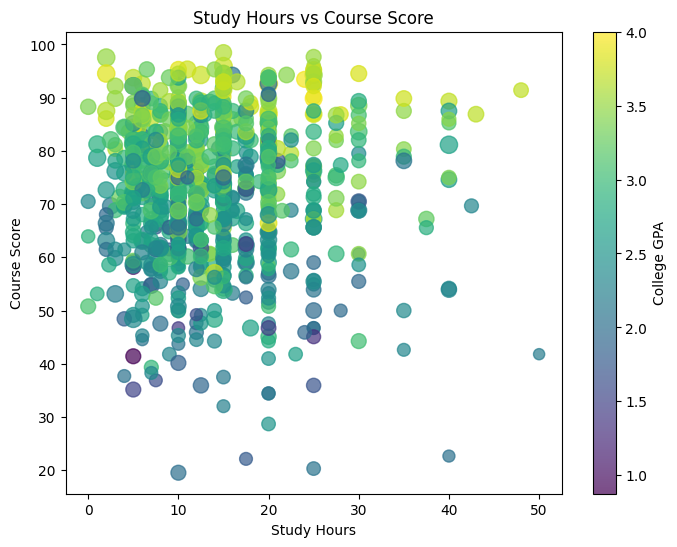

In [40]:
# Bubble plot showing relationship among four variables

plt.figure(figsize=(8,6))

plt.scatter(df["study"],
            df["score"],
            s=df["act"]*5,
            c=df["colgpa"],
            alpha=0.7)

plt.xlabel("Study Hours")

plt.ylabel("Course Score")

plt.title("Study Hours vs Course Score")

plt.colorbar(label="College GPA")

plt.show()

In [41]:
# Display final shape of cleaned dataset

print("Final Dataset Shape :", df.shape)

print("\nEDA Phase 1 Completed Successfully.")

Final Dataset Shape : (856, 18)

EDA Phase 1 Completed Successfully.


In [42]:
# EDA Course Project - Phase II

# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score


print("EDA PHASE II STARTED")
print("Dataset Shape:", df.shape)



EDA PHASE II STARTED
Dataset Shape: (856, 18)



--- 1D STATISTICS ---

Mean:
rownames    428.500000
age          19.406542
work          8.625584
study        13.917991
econhs        0.370327
colgpa        2.814686
hsgpa         3.342430
acteng       22.614486
actmth       23.200935
act          23.115654
mathscr       7.875000
male          0.500000
calculus      0.676402
attexc        0.296729
attgood       0.586449
fathcoll      0.524533
mothcoll      0.628505
score        72.599813
dtype: float64

Median:
rownames    428.5000
age          19.0000
work          8.0000
study        12.0000
econhs        0.0000
colgpa        2.8129
hsgpa         3.3215
acteng       23.0000
actmth       23.0000
act          23.0000
mathscr       8.0000
male          0.5000
calculus      1.0000
attexc        0.0000
attgood       1.0000
fathcoll      1.0000
mothcoll      1.0000
score        74.2200
dtype: float64

Mode:
rownames     1.00
age         19.00
work         0.00
study       10.00
econhs       0.00
colgpa       2.75
hsgpa        3.00
acteng

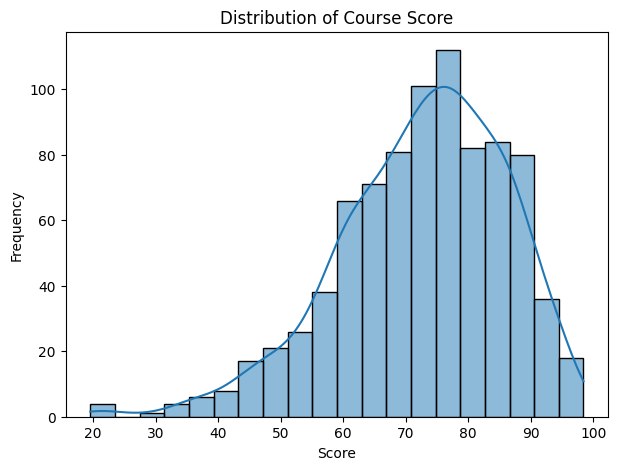

In [43]:
# 1D STATISTICAL ANALYSIS

# Mean
print("\n--- 1D STATISTICS ---")

print("\nMean:")
print(df.mean(numeric_only=True))

# Median
print("\nMedian:")
print(df.median(numeric_only=True))

# Mode
print("\nMode:")
print(df.mode(numeric_only=True).iloc[0])

# Variance
print("\nVariance:")
print(df.var(numeric_only=True))

# Standard Deviation
print("\nStandard Deviation:")
print(df.std(numeric_only=True))

# Minimum
print("\nMinimum:")
print(df.min(numeric_only=True))

# Maximum
print("\nMaximum:")
print(df.max(numeric_only=True))

# Skewness
print("\nSkewness:")
print(df.skew(numeric_only=True))

# Kurtosis
print("\nKurtosis:")
print(df.kurt(numeric_only=True))


# Distribution of Score
plt.figure(figsize=(7,5))
sns.histplot(df["score"], kde=True, bins=20)
plt.title("Distribution of Course Score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


--- 2D STATISTICS ---

Pearson Correlation:
           study      work       act    colgpa     hsgpa     score
study   1.000000 -0.007908 -0.137316  0.068338  0.073067  0.008800
work   -0.007908  1.000000  0.023306 -0.124766  0.018489 -0.167104
act    -0.137316  0.023306  1.000000  0.325039  0.414270  0.377270
colgpa  0.068338 -0.124766  0.325039  1.000000  0.479219  0.573519
hsgpa   0.073067  0.018489  0.414270  0.479219  1.000000  0.367549
score   0.008800 -0.167104  0.377270  0.573519  0.367549  1.000000

Covariance:
            study       work        act    colgpa     hsgpa       score
study   60.908635  -0.569572  -3.499978  0.286332  0.195839    0.920379
work    -0.569572  85.165204   0.702418 -0.618151  0.058598  -20.665497
act     -3.499978   0.702418  10.666141  0.569909  0.464647   16.511343
colgpa   0.286332  -0.618151   0.569909  0.288226  0.088356    4.126110
hsgpa    0.195839   0.058598   0.464647  0.088356  0.117943    1.691525
score    0.920379 -20.665497  16.511343  

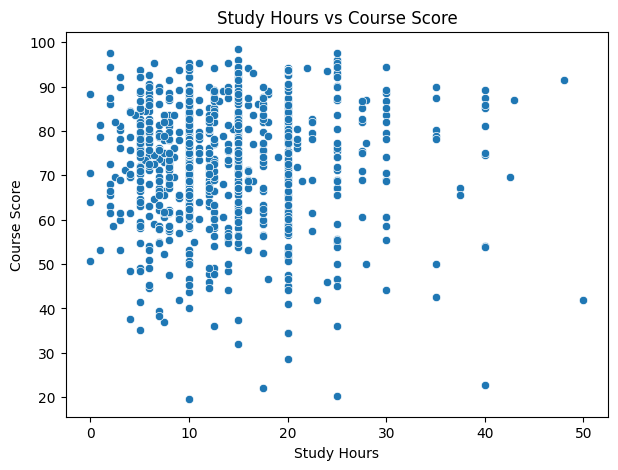

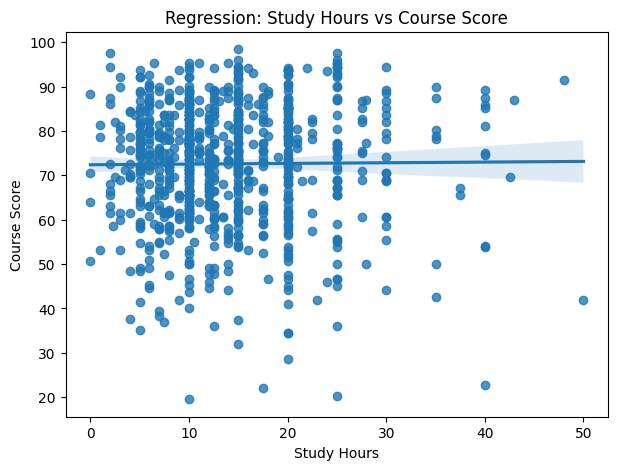

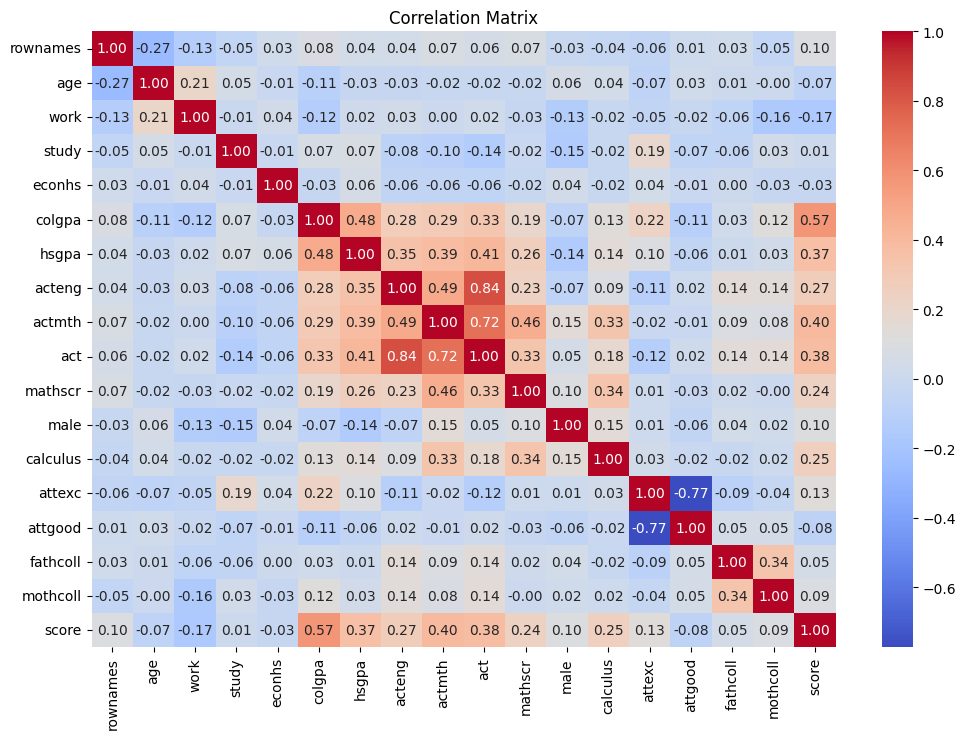

In [44]:
# 2D STATISTICAL ANALYSIS

print("\n--- 2D STATISTICS ---")

# Correlation
print("\nPearson Correlation:")
print(df[["study", "work", "act", "colgpa", "hsgpa", "score"]].corr())

# Covariance
print("\nCovariance:")
print(df[["study", "work", "act", "colgpa", "hsgpa", "score"]].cov())


# Pearson correlation: Study vs Score
r, p = pearsonr(df["study"], df["score"])

print("\nPearson Correlation - Study vs Score")
print("Correlation:", r)
print("P-value:", p)


# Spearman correlation
r_s, p_s = spearmanr(df["study"], df["score"])

print("\nSpearman Correlation - Study vs Score")
print("Correlation:", r_s)
print("P-value:", p_s)


# Scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="study", y="score")
plt.title("Study Hours vs Course Score")
plt.xlabel("Study Hours")
plt.ylabel("Course Score")
plt.show()


# Regression plot
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="study", y="score")
plt.title("Regression: Study Hours vs Course Score")
plt.xlabel("Study Hours")
plt.ylabel("Course Score")
plt.show()


# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


--- 3D STATISTICS ---


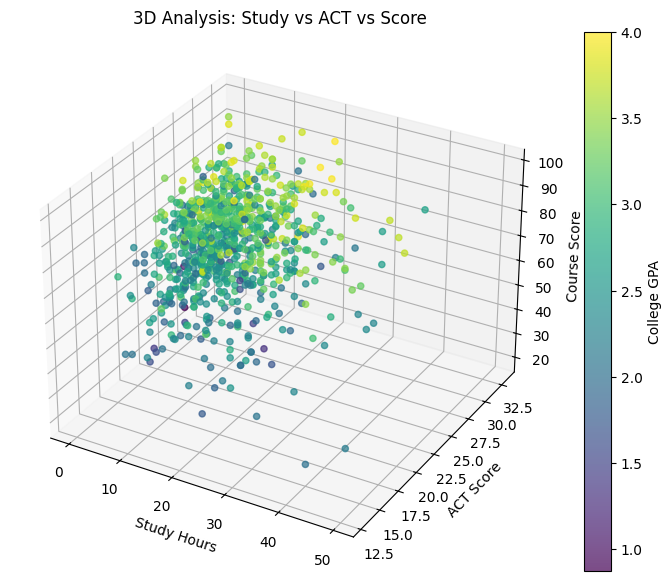

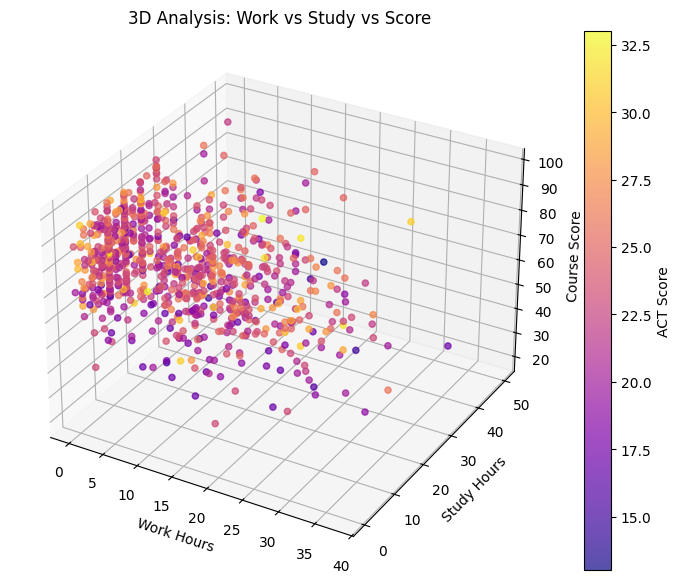

In [45]:
# 3D STATISTICAL ANALYSIS
print("\n--- 3D STATISTICS ---")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["study"],
    df["act"],
    df["score"],
    c=df["colgpa"],
    cmap="viridis",
    alpha=0.7
)

ax.set_xlabel("Study Hours")
ax.set_ylabel("ACT Score")
ax.set_zlabel("Course Score")

ax.set_title("3D Analysis: Study vs ACT vs Score")

plt.colorbar(scatter, label="College GPA")
plt.show()


# Another 3D relationship
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["work"],
    df["study"],
    df["score"],
    c=df["act"],
    cmap="plasma",
    alpha=0.7
)

ax.set_xlabel("Work Hours")
ax.set_ylabel("Study Hours")
ax.set_zlabel("Course Score")

ax.set_title("3D Analysis: Work vs Study vs Score")

plt.colorbar(scatter, label="ACT Score")
plt.show()



--- K-MEANS CLUSTERING ---

K-Means with K = 2
Cluster Centers:
[[ 0.05772222 -0.00667288  0.03713472 -0.52801588 -0.5879676  -0.58317624
  -0.66677685 -0.69647407 -0.45295182 -0.54412616]
 [-0.05207827  0.00602042 -0.03350377  0.47638766  0.53047743  0.52615457
   0.60158089  0.62837438  0.4086632   0.49092271]]

Cluster Counts:
0    406
1    450
Name: count, dtype: int64

WCSS for K = 2:
6706.2717927855165

WCSS Values:
K = 1 WCSS = 8559.999999999998
K = 2 WCSS = 6706.2717927855165
K = 3 WCSS = 6102.31585377051
K = 4 WCSS = 5667.221737261189
K = 5 WCSS = 5342.623501599494
K = 6 WCSS = 5115.734255386762
K = 7 WCSS = 4913.397941162586
K = 8 WCSS = 4745.152274708428
K = 9 WCSS = 4599.9183913822335
K = 10 WCSS = 4467.700096858386


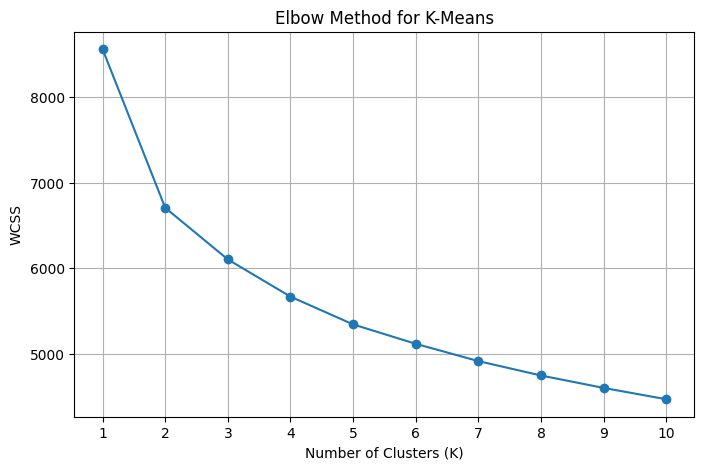


Final K-Means Results
Optimal K: 3

Cluster Counts:
KMeans_Cluster
0    399
1    260
2    197
Name: count, dtype: int64

Final WCSS:
6102.31585377051

Silhouette Score: 0.1268186480754016


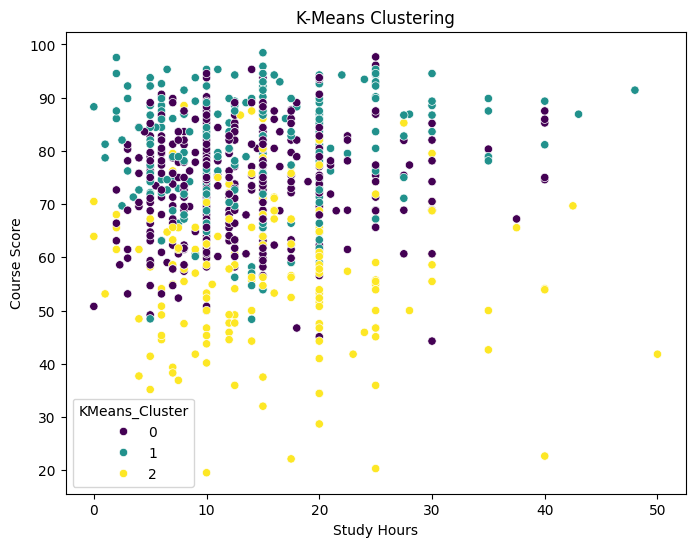


K-Means Cluster Summary:
                      age       work      study    colgpa     hsgpa  \
KMeans_Cluster                                                        
0               19.210526   7.545113  13.042105  2.831076  3.283634   
1               19.450000   8.890385  14.223077  3.160167  3.634065   
2               19.746193  10.464467  15.289340  2.325526  3.076614   

                   acteng     actmth        act   mathscr      score  
KMeans_Cluster                                                        
0               22.283208  22.726817  22.701754  7.822055  74.223434  
1               25.769231  26.707692  26.403846  8.892308  80.509654  
2               19.121827  19.532995  19.614213  6.639594  58.871980  


In [46]:
# K-MEANS CLUSTERING
print("\n--- K-MEANS CLUSTERING ---")

# Select variables for clustering
cluster_features = [
    "age",
    "work",
    "study",
    "colgpa",
    "hsgpa",
    "acteng",
    "actmth",
    "act",
    "mathscr",
    "score"
]

X = df[cluster_features].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# K-Means K = 2
kmeans2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters2 = kmeans2.fit_predict(X_scaled)

print("\nK-Means with K = 2")
print("Cluster Centers:")
print(kmeans2.cluster_centers_)

print("\nCluster Counts:")
print(pd.Series(clusters2).value_counts().sort_index())

print("\nWCSS for K = 2:")
print(kmeans2.inertia_)


# WCSS for K = 1 to 10
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


print("\nWCSS Values:")
for k, value in enumerate(wcss, 1):
    print("K =", k, "WCSS =", value)


# Elbow Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()


# Final K-Means
# Change this value according to the elbow point
optimal_k = 3

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans_final.fit_predict(X_scaled)


print("\nFinal K-Means Results")
print("Optimal K:", optimal_k)

print("\nCluster Counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())

print("\nFinal WCSS:")
print(kmeans_final.inertia_)


# Silhouette Score
silhouette = silhouette_score(
    X_scaled,
    df["KMeans_Cluster"]
)

print("\nSilhouette Score:", silhouette)


# K-Means visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="study",
    y="score",
    hue="KMeans_Cluster",
    palette="viridis"
)

plt.title("K-Means Clustering")
plt.xlabel("Study Hours")
plt.ylabel("Course Score")

plt.show()


# Cluster summary
print("\nK-Means Cluster Summary:")
print(
    df.groupby("KMeans_Cluster")[cluster_features].mean()
)


--- HIERARCHICAL CLUSTERING ---


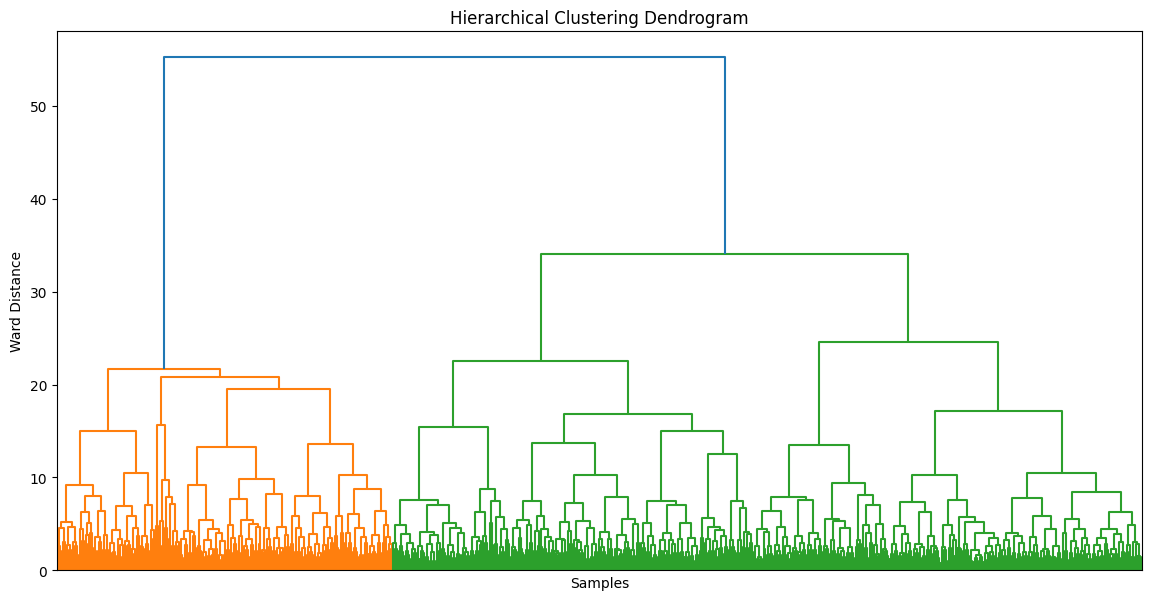


Hierarchical Cluster Assignments:
    rownames  Hierarchical_Cluster
0          1                     2
1          2                     2
2          3                     1
3          4                     2
4          5                     2
5          6                     2
6          7                     1
7          8                     2
8          9                     2
9         10                     1
10        11                     2
11        12                     1
12        13                     3
13        14                     1
14        15                     2
15        16                     2
16        17                     1
17        18                     3
18        19                     2
19        20                     2

Number of Samples in Each Cluster:
Hierarchical_Cluster
1    265
2    285
3    306
Name: count, dtype: int64

Hierarchical Cluster Summary:
                            age       work      study    colgpa     hsgpa  \
Hierarchical

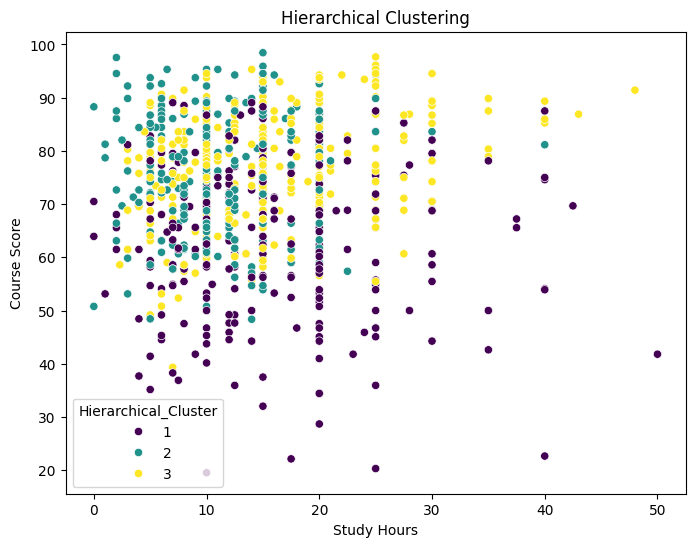


Hierarchical Clustering Silhouette Score:
0.08465867680569716


In [47]:
# HIERARCHICAL CLUSTERING
print("\n--- HIERARCHICAL CLUSTERING ---")


# Standardized data already created above

# Ward linkage
Z = linkage(
    X_scaled,
    method="ward"
)


# Dendrogram
plt.figure(figsize=(14,7))

dendrogram(
    Z,
    truncate_mode=None,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Ward Distance")

plt.show()


# Create 3 clusters
hier_clusters = fcluster(
    Z,
    t=3,
    criterion="maxclust"
)

df["Hierarchical_Cluster"] = hier_clusters


# Cluster assignments
print("\nHierarchical Cluster Assignments:")
print(df[["rownames", "Hierarchical_Cluster"]].head(20))


# Number of samples in each cluster
print("\nNumber of Samples in Each Cluster:")
print(df["Hierarchical_Cluster"].value_counts().sort_index())


# Hierarchical cluster summary
print("\nHierarchical Cluster Summary:")
print(
    df.groupby("Hierarchical_Cluster")[cluster_features].mean()
)


# Hierarchical clustering visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="study",
    y="score",
    hue="Hierarchical_Cluster",
    palette="viridis"
)

plt.title("Hierarchical Clustering")
plt.xlabel("Study Hours")
plt.ylabel("Course Score")

plt.show()


# Silhouette score
hier_silhouette = silhouette_score(
    X_scaled,
    hier_clusters
)

print("\nHierarchical Clustering Silhouette Score:")
print(hier_silhouette)


In [48]:

# FINAL DATASET
print("\nFinal Dataset Shape:", df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nEDA PHASE II COMPLETED SUCCESSFULLY")


Final Dataset Shape: (856, 20)

Final Columns:
['rownames', 'age', 'work', 'study', 'econhs', 'colgpa', 'hsgpa', 'acteng', 'actmth', 'act', 'mathscr', 'male', 'calculus', 'attexc', 'attgood', 'fathcoll', 'mothcoll', 'score', 'KMeans_Cluster', 'Hierarchical_Cluster']

EDA PHASE II COMPLETED SUCCESSFULLY
